In [1]:
import os
import copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import scipy 

from matplotlib.patches import Ellipse

from IFlogdensity.contam_ml_de import *

import seaborn as sns
from IPython.display import Markdown as md
from datetime import datetime as dt

In [2]:
os.chdir('../data')
true_data = np.load('geyser.npy').astype(np.float64)
df = copy.deepcopy(true_data[:, 0]).reshape(-1, 1)

# original data with 108.0 removed 
data_waiting = df[df != 108.0]

grid_points = np.arange(1., 202.)
bw = 5.
kernel_type = 'gaussian_poly2'
plot_domain = (1., 210.)
plot_pts_cnt = 3000

In [3]:
from dekef.base_density import *
base_density = BasedenGamma(data_waiting, 36., 2.)
new_data = np.linspace(plot_domain[0], plot_domain[1], plot_pts_cnt)
base_den_vals = base_density.baseden_eval(new_data.reshape(-1, 1))
print(base_density.a, base_density.scale)

36.0 2.0


In [4]:
sm_log_pen_param = -8.
ml_log_pen_param = -15. #-np.inf
contam_data_list = [120., 180.]

In [5]:
sm_save_folder = (f'PenSM-FinKEF-data=waiting-bw={bw}-kernel={kernel_type}-' +
                  f'sample-inffun-plotdomain={plot_domain}-plotcnts={plot_pts_cnt}-' + 
                  f'baseden=gamma-{base_density.a}-{base_density.scale}-grid_points=1-202-1-inffun-logden-vs-den')

# if not os.path.isdir(sm_save_folder):
#     os.mkdir(sm_save_folder)

ml_save_folder = (f'PenML-FinKEF-data=waiting-bw={bw}-kernel={kernel_type}-' +
                  f'sample-inffun-plotdomain={plot_domain}-plotcnts={plot_pts_cnt}-' + 
                  f'baseden=gamma-{base_density.a}-{base_density.scale}-grid_points=1-202-1-inffun-logden-vs-den')

# if not os.path.isdir(ml_save_folder):
#     os.mkdir(ml_save_folder)

## Computing the ML density estimates 

In [ ]:
seed_no = 1

In [ ]:
# compute the density estimate without contamination 
uncontam_ml = ContamMLDensityEstimate(
    data = data_waiting, 
    contam_data = np.array([contam_data_list[0]]).reshape(-1, 1), 
    contam_weight = 0., 
    penalty_param = np.exp(ml_log_pen_param), 
    base_density = base_density,
    r1 = 1.0, 
    r2 = 0.0, 
    c = 0., 
    bw = bw, 
    kernel_type = 'gaussian_poly2')

step_size = 0.6

gdalgo_params = negloglik_optalgoparams(
        start_pt=np.zeros((grid_points.shape[0], 1)),
        step_size=step_size, 
        max_iter=100,
        rel_tol=1e-5,
        abs_tol=0.05)

bmc_params = batch_montecarlo_params(
        mc_batch_size=5000,
        mc_tol=5e-3)

In [ ]:
np.random.seed(seed_no)
print(f'start time = {dt.now().strftime("%H:%M:%S")}')
uncontam_coef = uncontam_ml.coef_grid_points(
    optalgo_params = gdalgo_params, 
    batchmc_params = bmc_params, 
    algo = 'gd', 
    step_size_factor = 1., 
    grid_points = grid_points, 
    print_error = True)
print(f'end time = {dt.now().strftime("%H:%M:%S")}')

In [ ]:
kernel_function_grid = GaussianPoly2(
    data=grid_points.reshape(-1, 1),
    r1=uncontam_ml.r1,
    r2=uncontam_ml.r2,
    c=uncontam_ml.c,
    bw=uncontam_ml.bw)

gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

uncontam_norm = np.sqrt(uncontam_coef[0].T @ gram_grid @ uncontam_coef[0]).item()

uncontam_norm

In [ ]:
uncontam_logden_vals = uncontam_ml.log_density(new_data, uncontam_coef, True)
plt.figure(figsize = (10, 10))
plt.plot(new_data, np.exp(uncontam_logden_vals), color = 'tab:blue', lw = 3.0)
plt.hist(data_waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
plt.show()

In [ ]:
file_name_newdata = f'/new_data.npy'
np.save(ml_save_folder + file_name_newdata, new_data)

file_name_grid_points = f'/grid_points.npy'
np.save(ml_save_folder + file_name_grid_points, grid_points)

file_name_coef = f'/logpenparam={ml_log_pen_param}-uncontam-coef.npy'
np.save(ml_save_folder + file_name_coef, uncontam_coef[0])

file_name_diff = f'/logpenparam={ml_log_pen_param}-uncontam-logden-newdata.npy'
np.save(ml_save_folder + file_name_diff, uncontam_logden_vals)

file_name_diff = f'/logpenparam={ml_log_pen_param}-uncontam-den-newdata.npy'
np.save(ml_save_folder + file_name_diff, np.exp(uncontam_logden_vals))

In [ ]:
result = []

for contam_pt in contam_data_list: 
    
    print('*' * 50)
    print(f'contam data = {contam_pt}')
    
    data_waiting2 = np.append(data_waiting, contam_pt)
    print(data_waiting2)
    print(len(data_waiting2))
    
    contam_ml = ContamMLDensityEstimate(
        data = data_waiting2, 
        contam_data = np.array(contam_pt).reshape(-1, 1), 
        contam_weight = 0., 
        penalty_param = np.exp(ml_log_pen_param), 
        base_density = base_density,
        r1 = 1.0, 
        r2 = 0.0, 
        c = 0., 
        bw = bw, 
        kernel_type = 'gaussian_poly2')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    contam_coef = contam_ml.coef_grid_points(
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        algo = 'gd', 
        step_size_factor = 1.0, 
        grid_points = grid_points, 
        print_error = True)
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=uncontam_ml.r1,
        r2=uncontam_ml.r2,
        c=uncontam_ml.c,
        bw=uncontam_ml.bw)
    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))
    contam_norm = np.sqrt(contam_coef[0].T @ gram_grid @ contam_coef[0]).item()
    
    contam_logden_vals = contam_ml.log_density(new_data, contam_coef, True)

    plt.figure(figsize = (10, 10))
    plt.plot(new_data, np.exp(contam_logden_vals), color = 'tab:blue', lw = 3.0)
    plt.hist(data_waiting2, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    plt.axvline(x = contam_pt, color = 'k', linestyle='--')
    plt.show()
    
    print(len(data_waiting2))
    IF_vals_logden = (contam_logden_vals - uncontam_logden_vals) * len(data_waiting2)
    IF_vals_den = (np.exp(contam_logden_vals) - np.exp(uncontam_logden_vals)) * len(data_waiting2)

    plt.figure(figsize = (10, 10))
    plt.plot(new_data, IF_vals_logden, color = 'tab:blue', lw = 3.0)
    plt.axvline(x = contam_pt, color = 'k', linestyle='--')
    plt.show()
    
    plt.figure(figsize = (10, 10))
    plt.plot(new_data, IF_vals_den, color = 'tab:blue', lw = 3.0)
    plt.axvline(x = contam_pt, color = 'k', linestyle='--')
    plt.show()
    
    # save coefficients 
    file_name_coef = f'/contamdata={contam_pt}-logpenparam={ml_log_pen_param}-contam-coef.npy'
    np.save(ml_save_folder + file_name_coef, contam_coef[0])

    file_name_diff = f'/contamdata={contam_pt}-logpenparam={ml_log_pen_param}-contam-logden-newdata.npy'
    np.save(ml_save_folder + file_name_diff, contam_logden_vals)
    
    file_name_diff = f'/contamdata={contam_pt}-logpenparam={ml_log_pen_param}-contam-den-newdata.npy'
    np.save(ml_save_folder + file_name_diff, np.exp(contam_logden_vals))
    
    file_name_ifvals = f'/contamdata={contam_pt}-logpenparam={ml_log_pen_param}-IF-logden-newdata.npy'
    np.save(ml_save_folder + file_name_ifvals, IF_vals_logden)
    
    file_name_ifvals = f'/contamdata={contam_pt}-logpenparam={ml_log_pen_param}-IF-den-newdata.npy'
    np.save(ml_save_folder + file_name_ifvals, IF_vals_den)
    

## Computing the penalized SM density estimates 

In [ ]:
from IFlogdensity.contam_sm_de_finkernelexpfam import *

In [ ]:
len(data_waiting)

In [ ]:
r1, r2, c = 1., 0., 0.
uncontam_sm = ContamSMFinKernelExpFam(
    data=data_waiting,
    contam_data=np.array(contam_data_list[0]).reshape(-1, 1),
    grid_points=grid_points,
    contam_weight=0.,
    penalty_param=np.exp(sm_log_pen_param),
    base_density=base_density,
    r1=r1,
    r2=r2,
    c=c,
    bw=bw,
    kernel_type='gaussian_poly2')

uncontam_coef = uncontam_sm.coef()

gram_mat = uncontam_sm.gram_matrix
uncontam_norm = np.sqrt(uncontam_coef.T @ gram_mat @ uncontam_coef).item()

uncontam_logden_vals = uncontam_sm.log_density(new_data, uncontam_coef, True)

file_name_newdata = f'/new_data.npy'
np.save(sm_save_folder + file_name_newdata, new_data)

file_name_coef = f'/logpenparam={sm_log_pen_param}-uncontam-coef.npy'
np.save(sm_save_folder + file_name_coef, uncontam_coef)

file_name_diff = f'/logpenparam={sm_log_pen_param}-uncontam-logden-newdata.npy'
np.save(sm_save_folder + file_name_diff, uncontam_logden_vals)

file_name_diff = f'/logpenparam={sm_log_pen_param}-uncontam-den-newdata.npy'
np.save(sm_save_folder + file_name_diff, np.exp(uncontam_logden_vals))

In [ ]:
plt.figure(figsize = (10, 10))
plt.plot(new_data, np.exp(uncontam_logden_vals), color = 'tab:blue', lw = 3.0)
plt.hist(data_waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
plt.show()

In [ ]:
for contam_data in [120., 180.]: # contam_data_list:

    print('*' * 50)
    print(f'contam data = {contam_data}')
    
    data_waiting2 = np.append(data_waiting, contam_data)
    print(data_waiting2)

    contam_sm = ContamSMFinKernelExpFam(
        data=data_waiting2,
        contam_data=np.array(contam_data).reshape(-1, 1),
        grid_points=grid_points,
        contam_weight=0.,
        penalty_param=np.exp(sm_log_pen_param),
        base_density=base_density,
        r1=r1,
        r2=r2,
        c=c,
        bw=bw,
        kernel_type='gaussian_poly2')

    contam_coef = contam_sm.coef()

    gram_mat = contam_sm.gram_matrix
    contam_norm = np.sqrt(contam_coef.T @ gram_mat @ contam_coef).item()

    contam_logden_vals = contam_sm.log_density(new_data, contam_coef, True)
    
    plt.figure(figsize = (10, 10))
    plt.plot(new_data, np.exp(contam_logden_vals), color = 'tab:blue', lw = 3.0)
    plt.hist(data_waiting2, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    plt.axvline(x = contam_data, color = 'k', linestyle='--')
    plt.show()
    
    IF_vals = (contam_logden_vals - uncontam_logden_vals) * len(data_waiting2)

    plt.figure(figsize = (10, 10))
    plt.plot(new_data, IF_vals, color = 'tab:blue', lw = 3.0)
    plt.axvline(x = contam_data, color = 'k', linestyle='--')
    plt.show()
    
    plt.figure(figsize = (10, 10))
    plt.plot(new_data, (np.exp(contam_logden_vals) - np.exp(uncontam_logden_vals)) * len(data_waiting2), 
             color = 'tab:red', lw = 3.0)
    plt.axvline(x = contam_data, color = 'k', linestyle='--')
    plt.show()
    
    # save coefficients
    file_name_coef = f'/logpenparam={sm_log_pen_param}-contam_data={contam_data}-contam-coef.npy'
    np.save(sm_save_folder + file_name_coef, contam_coef)

    file_name_diff = f'/logpenparam={sm_log_pen_param}-contam_data={contam_data}-contam-logden-newdata.npy'
    np.save(sm_save_folder + file_name_diff, contam_logden_vals)

    file_name_ifvals = f'/logpenparam={sm_log_pen_param}-contam_data={contam_data}-IF-logden-newdata.npy'
    np.save(sm_save_folder + file_name_ifvals, IF_vals)
    
    file_name_denvals = f'/logpenparam={sm_log_pen_param}-contam_data={contam_data}-den-newdata.npy'
    np.save(sm_save_folder + file_name_denvals, np.exp(contam_logden_vals))
    
    IF_denvals = (np.exp(contam_logden_vals) - np.exp(uncontam_logden_vals)) * len(data_waiting2)
    
    file_name_ifvals = f'/logpenparam={sm_log_pen_param}-contam_data={contam_data}-IF-den-newdata.npy'
    np.save(sm_save_folder + file_name_ifvals, IF_denvals)
    

### Make plots 

In [6]:
sm_log_pen_param = -11.

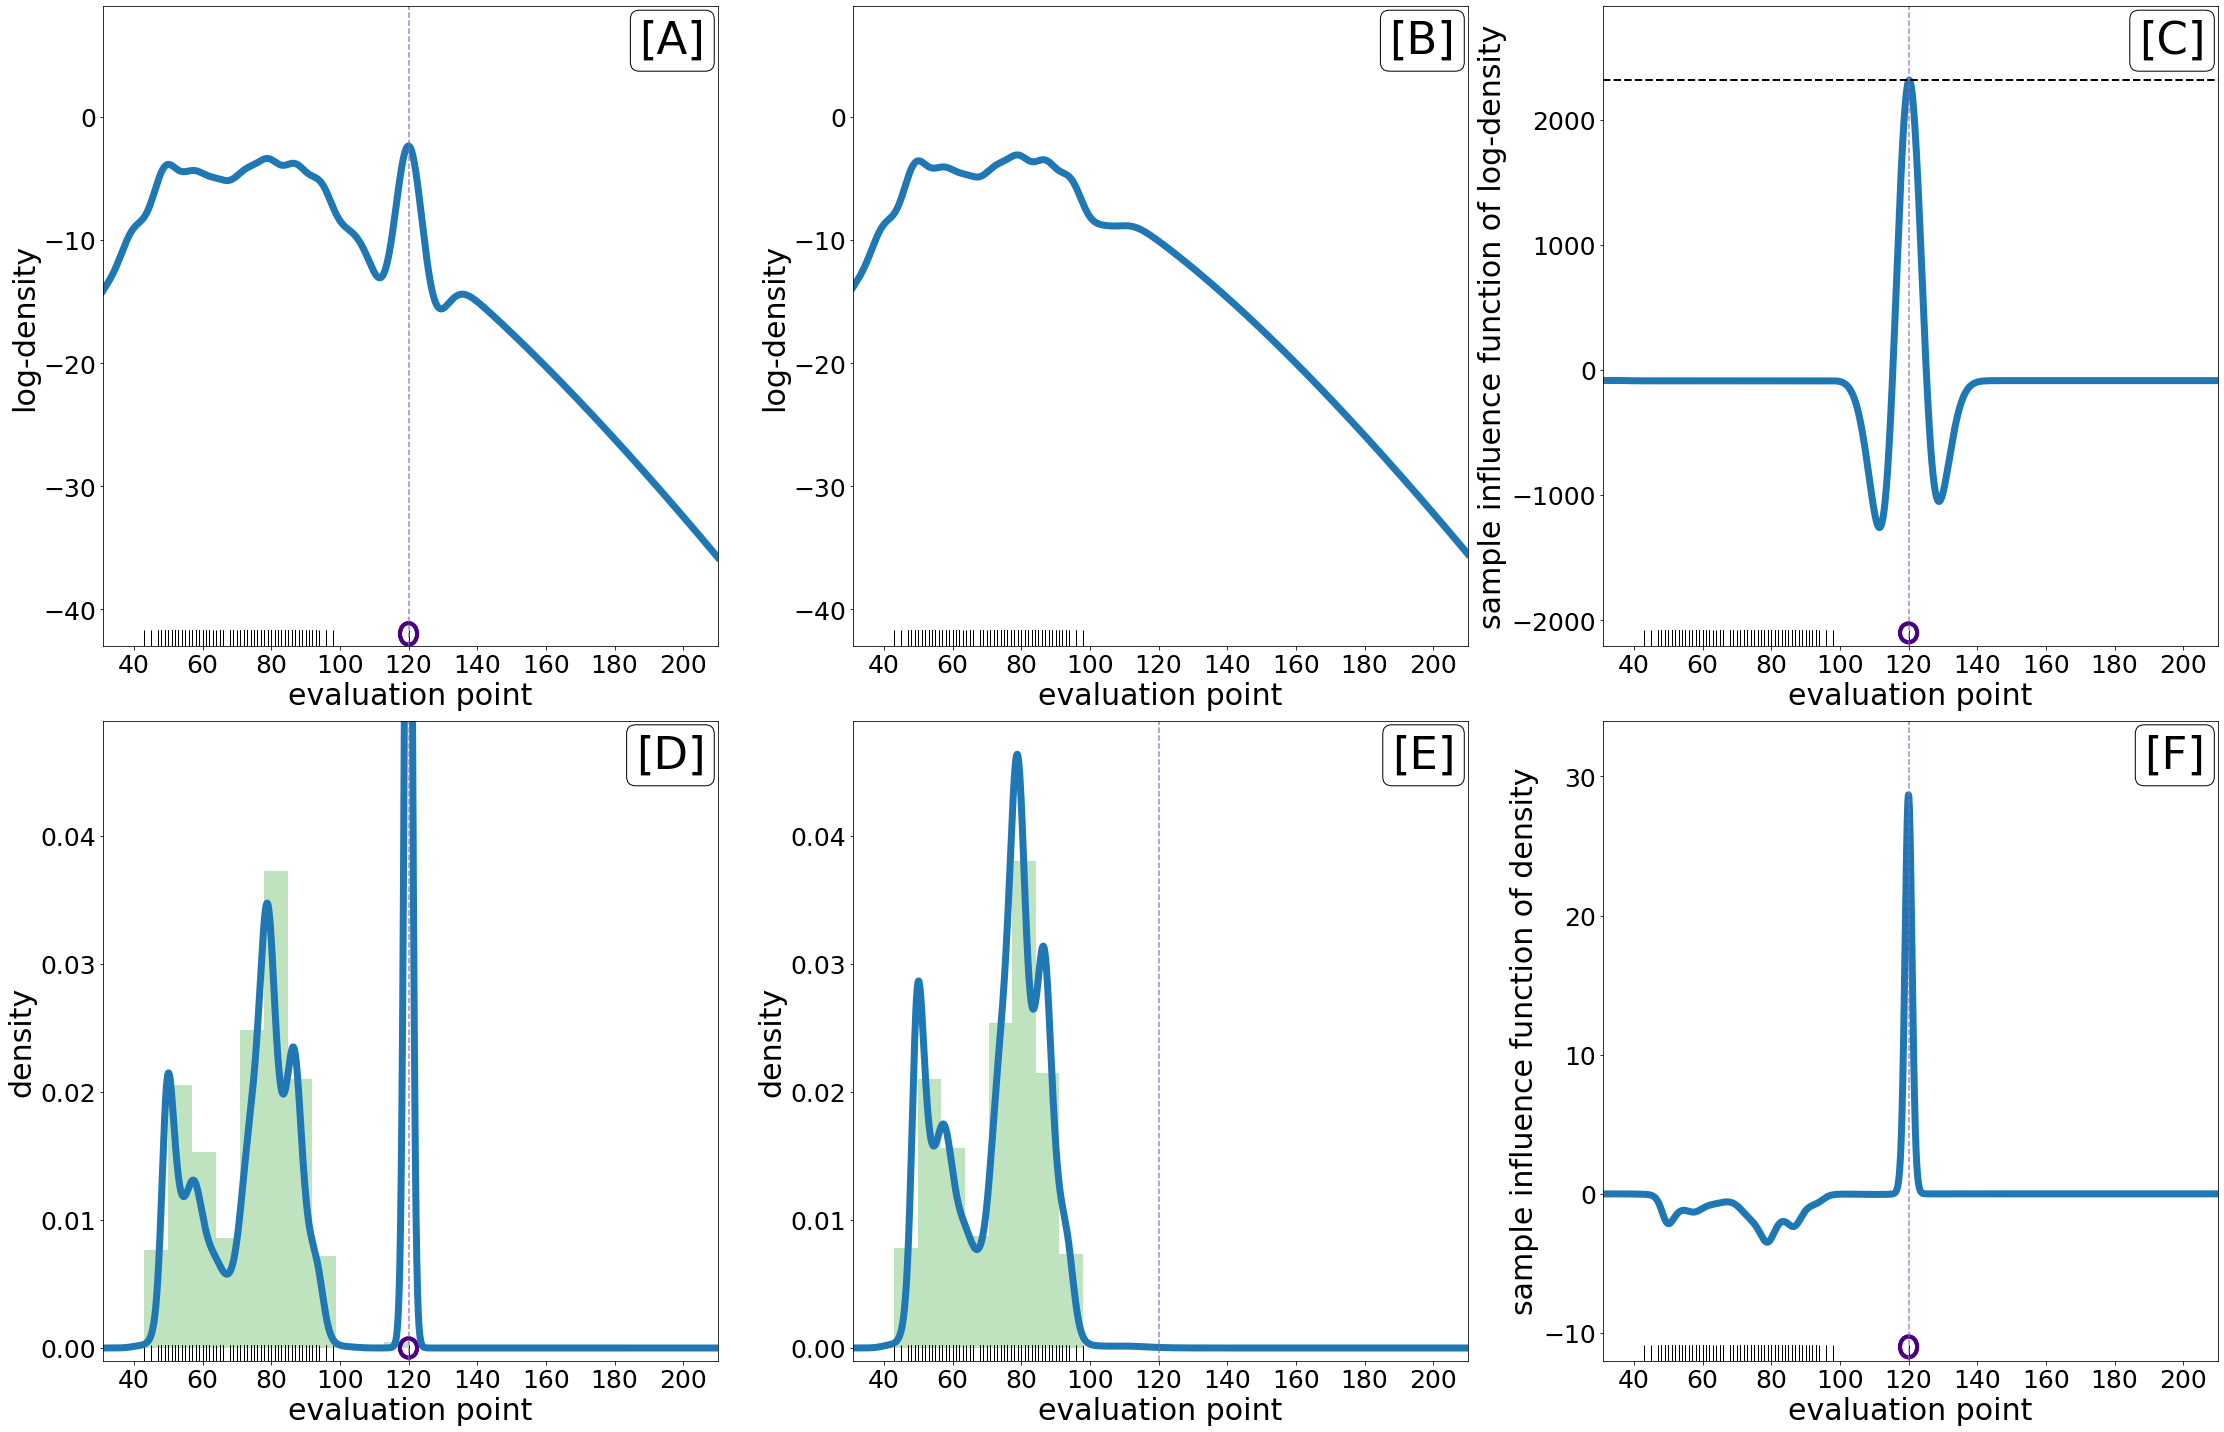

In [8]:
label_fontsize = 30
info_fontsize = 45
tick_fontsize = 25
legend_fontsize = 30
linewidth = 7.0
x_label1 = 'waiting'
x_label = r'evaluation point'
info_coord = (0.98, 0.98)
horizontalalignment, verticalalignment = 'right', 'top'

den_plot_xlim = (31., 210.)
logden_plot_ylim = (-43., 9.)
den_plot_ylim = (-0.001, 0.049)

contam_data = 120.
legend_loc = 'lower right'

xticks = [40, 60, 80, 100, 120, 140, 160, 180, 200]

nrows, ncols = 2, 3
fig = plt.figure(figsize=(31, 20))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

SM_uncontam_logden = np.load(sm_save_folder + 
                             f'/logpenparam={sm_log_pen_param}-uncontam-logden-newdata.npy')
# ML_uncontam_logden = np.load(ml_save_folder + 
#                              f'/logpenparam={ml_log_pen_param}-uncontam-logden-newdata.npy')
SM_contam_logden = np.load(sm_save_folder + 
                           f'/logpenparam={sm_log_pen_param}-contam_data={contam_data}-contam-logden-newdata.npy')
# ML_contam_logden = np.load(ml_save_folder + 
#                            f'/contamdata={contam_data}-logpenparam={ml_log_pen_param}-contam-logden-newdata.npy')
# ML_IF_logden_vals = np.load(ml_save_folder + 
#                             f'/contamdata={contam_data}-logpenparam={ml_log_pen_param}-IF-logden-newdata.npy')

# ========================================================================================
# ----------------------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(new_data.flatten(), SM_contam_logden, 
         linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')
# ax1.plot(new_data.flatten(), ML_contam_logden, 
#          linewidth = linewidth, color = 'tab:red', label = 'Maximum Likelihood')


sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax1, color = 'black')
sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax1, color = 'black')
ax1.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax1.set_xlim(den_plot_xlim)
ax1.set_ylim(logden_plot_ylim)
ax1.set_xlabel(x_label, fontsize = label_fontsize)
ax1.set_ylabel(r'log-density', fontsize = label_fontsize)
ax1.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax1.legend(loc = legend_loc, fontsize = label_fontsize)
ax1.add_patch(ax1.add_artist(Ellipse((contam_data, logden_plot_ylim[0] + 1.), 5., 1.75, 
                                     color = 'indigo', fill = False, linewidth = 4.0)))
ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, size = tick_fontsize)

info = "[{letter}]".format(letter = chr(65))
ax1.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax1.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})


# ----------------------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(new_data.flatten(), SM_uncontam_logden, 
         linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')
# ax2.plot(new_data.flatten(), ML_contam_logden, 
#          linewidth = linewidth, color = 'tab:red', label = 'Maximum Likelihood')

ax2.set_xticks(xticks)
ax2.set_xticklabels(xticks, size = tick_fontsize)
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax2, color = 'black')
# sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax2, color = 'black')
# ax2.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax2.set_xlim(den_plot_xlim)
ax2.set_ylim(logden_plot_ylim)
ax2.set_xlabel(x_label, fontsize = label_fontsize)
ax2.set_ylabel(r'log-density', fontsize = label_fontsize)
ax2.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax2.legend(loc = legend_loc, fontsize = label_fontsize)

info = "[{letter}]".format(letter = chr(66))
ax2.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax2.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

# ----------------------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(new_data.flatten(), (SM_contam_logden - SM_uncontam_logden) * (len(data_waiting) + 1), 
         linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')
# ax3.plot(new_data.flatten(), ML_IF_logden_vals, 
#          linewidth = linewidth, color = 'tab:red', label = 'Maximum Likelihood')

ax3.set_xticks(xticks)
ax3.set_xticklabels(xticks, size = tick_fontsize)
ax3.axhline(np.max((SM_contam_logden - SM_uncontam_logden) * (len(data_waiting) + 1)), 
            0, 1, ls = '--', color = 'k', linewidth = 2)
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax3, color = 'black')
sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax3, color = 'black')
ax3.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax3.set_xlim(den_plot_xlim)
# ax3.set_ylim(den_plot_ylim)
ax3.set_xlabel(x_label, fontsize = label_fontsize)
ax3.set_ylabel(r'sample influence function of log-density', fontsize = label_fontsize)
ax3.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax3.legend(loc = legend_loc, fontsize = label_fontsize)
ax3.add_patch(ax3.add_artist(Ellipse((contam_data, -2100.), 5., 150, 
                                     color = 'indigo', fill = False, linewidth = 4.0)))

info = "[{letter}]".format(letter = chr(67))
ax3.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax3.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

# ========================================================================================
# ----------------------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[1, 0])
ax1.plot(new_data.flatten(), np.exp(SM_contam_logden), 
         linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')
# ax1.plot(new_data.flatten(), np.exp(ML_contam_logden), 
#          linewidth = linewidth, color = 'tab:red', label = 'Maximum Likelihood')

ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, size = tick_fontsize)
ax1.hist(np.append(data_waiting, contam_data), bins='fd', density = True, alpha = 0.3, color = 'tab:green')
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax1, color = 'black')
sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax1, color = 'black')
ax1.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax1.set_xlim(den_plot_xlim)
ax1.set_ylim(den_plot_ylim)
ax1.set_xlabel(x_label, fontsize = label_fontsize)
ax1.set_ylabel(r'density', fontsize = label_fontsize)
ax1.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax1.legend(loc = legend_loc, fontsize = label_fontsize)
ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 5., 0.0015, 
                                     color = 'indigo', fill = False, linewidth = 4.0)))

info = "[{letter}]".format(letter = chr(68))
ax1.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax1.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

# ----------------------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(new_data.flatten(), np.exp(SM_uncontam_logden), 
         linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')
# ax2.plot(new_data.flatten(), np.exp(ML_contam_logden), 
#          linewidth = linewidth, color = 'tab:red', label = 'Maximum Likelihood')

ax2.set_xticks(xticks)
ax2.set_xticklabels(xticks, size = tick_fontsize)
ax2.hist(data_waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax2, color = 'black')
# sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax2, color = 'black')
ax2.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax2.set_xlim(den_plot_xlim)
ax2.set_ylim(den_plot_ylim)
ax2.set_xlabel(x_label, fontsize = label_fontsize)
ax2.set_ylabel(r'density', fontsize = label_fontsize)
ax2.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax2.legend(loc = legend_loc, fontsize = label_fontsize)

info = "[{letter}]".format(letter = chr(69))
ax2.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax2.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

# ----------------------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 2])
ax3.plot(new_data.flatten(), (np.exp(SM_contam_logden) - np.exp(SM_uncontam_logden)) * (len(data_waiting) + 1), 
         linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')
# ax3.plot(new_data.flatten(), (np.exp(ML_contam_logden) - np.exp(ML_uncontam_logden)) * (len(data_waiting) + 1), 
#          linewidth = linewidth, color = 'tab:red', label = 'Maximum Likelihood')

ax3.set_xticks(xticks)
ax3.set_xticklabels(xticks, size = tick_fontsize)
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax3, color = 'black')
sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax3, color = 'black')
# ax3.axhline(np.max((np.exp(SM_contam_logden) - np.exp(SM_uncontam_logden)) * (len(data_waiting) + 1)), 
#             0, 1, ls = '--', color = 'k', linewidth = 2)
ax3.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax3.set_xlim(den_plot_xlim)
# ax3.set_ylim(den_plot_ylim)
ax3.set_xlabel(x_label, fontsize = label_fontsize)
ax3.set_ylabel(r'sample influence function of density', fontsize = label_fontsize)
ax3.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax3.legend(loc = legend_loc, fontsize = label_fontsize)
# ax3.add_patch(ax3.add_artist(Ellipse((contam_data, -.00195), 5., 0.0001, 
#                                      color = 'indigo', fill = False, linewidth = 4.0))) # 180
ax3.add_patch(ax3.add_artist(Ellipse((contam_data, -11.), 5., 1.5,  
                                     color = 'indigo', fill = False, linewidth = 4.0))) # 120

info = "[{letter}]".format(letter = chr(70))
ax3.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax3.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'../plots/comparison-inffunden-inffunlogden-logdensity-density-contam-sm-logpenparam={sm_log_pen_param}-data={contam_data}-gamma-{base_density.a}-{base_density.scale}.pdf', 
            bbox_inches = 'tight')

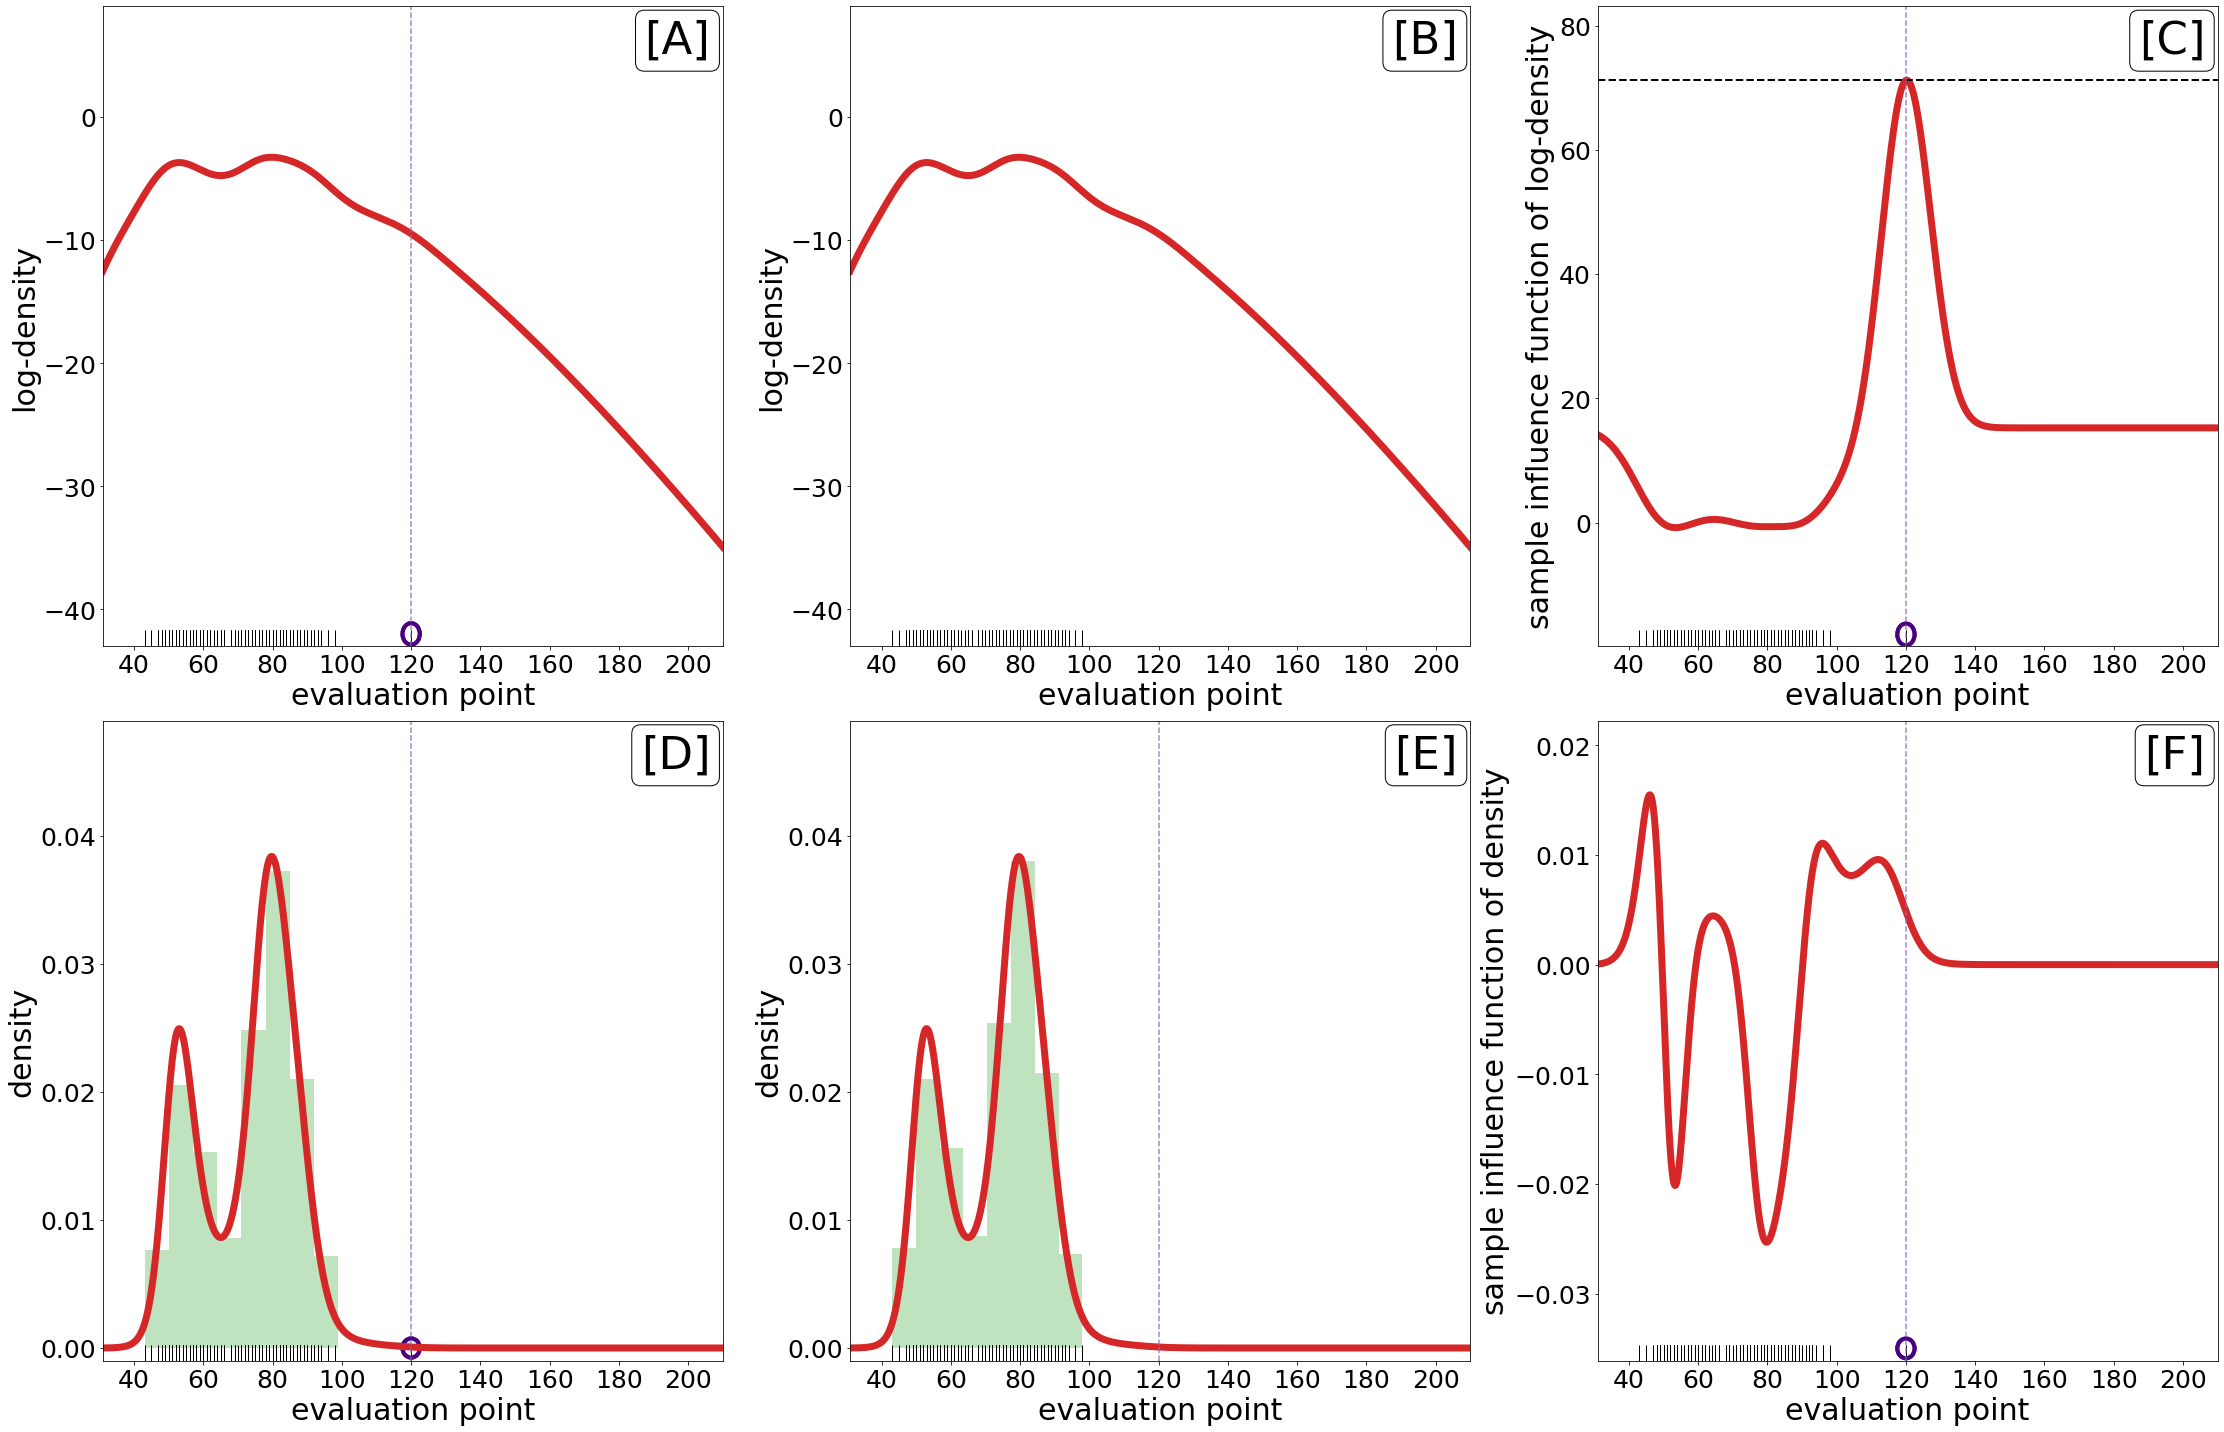

In [10]:
label_fontsize = 30
info_fontsize = 45
tick_fontsize = 25
legend_fontsize = 30
linewidth = 7.0
x_label = r'evaluation point'
info_coord = (0.98, 0.98)
horizontalalignment, verticalalignment = 'right', 'top'

den_plot_xlim = (31., 210.)
logden_plot_ylim = (-43., 9.)
den_plot_ylim = (-0.001, 0.049)

contam_data = 120.
legend_loc = 'lower right'

xticks = [40, 60, 80, 100, 120, 140, 160, 180, 200]

nrows, ncols = 2, 3
fig = plt.figure(figsize=(31, 20))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

# SM_uncontam_logden = np.load(sm_save_folder + 
#                              f'/logpenparam={sm_log_pen_param}-uncontam-logden-newdata.npy')
ML_uncontam_logden = np.load(ml_save_folder + 
                             f'/logpenparam={ml_log_pen_param}-uncontam-logden-newdata.npy')
# SM_contam_logden = np.load(sm_save_folder + 
#                            f'/logpenparam={sm_log_pen_param}-contam_data={contam_data}-contam-logden-newdata.npy')
ML_contam_logden = np.load(ml_save_folder + 
                           f'/contamdata={contam_data}-logpenparam={ml_log_pen_param}-contam-logden-newdata.npy')

# ========================================================================================
# ----------------------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
# ax1.plot(new_data.flatten(), SM_contam_logden, 
#          linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')
ax1.plot(new_data.flatten(), ML_contam_logden, 
         linewidth = linewidth, color = 'tab:red', label = 'Maximum Likelihood')

sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax1, color = 'black')
sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax1, color = 'black')
ax1.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax1.set_xlim(den_plot_xlim)
ax1.set_ylim(logden_plot_ylim)
ax1.set_xlabel(x_label, fontsize = label_fontsize)
ax1.set_ylabel(r'log-density', fontsize = label_fontsize)
ax1.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax1.legend(loc = legend_loc, fontsize = label_fontsize)
ax1.add_patch(ax1.add_artist(Ellipse((contam_data, logden_plot_ylim[0] + 1.), 5., 1.75, 
                                     color = 'indigo', fill = False, linewidth = 4.0)))
ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, size = tick_fontsize)

info = "[{letter}]".format(letter = chr(65))
ax1.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax1.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})


# ----------------------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
# ax2.plot(new_data.flatten(), SM_uncontam_logden, 
#          linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')
ax2.plot(new_data.flatten(), ML_contam_logden, 
         linewidth = linewidth, color = 'tab:red', label = 'Maximum Likelihood')

ax2.set_xticks(xticks)
ax2.set_xticklabels(xticks, size = tick_fontsize)
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax2, color = 'black')
# sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax2, color = 'black')
# ax2.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax2.set_xlim(den_plot_xlim)
ax2.set_ylim(logden_plot_ylim)
ax2.set_xlabel(x_label, fontsize = label_fontsize)
ax2.set_ylabel(r'log-density', fontsize = label_fontsize)
ax2.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax2.legend(loc = legend_loc, fontsize = label_fontsize)

info = "[{letter}]".format(letter = chr(66))
ax2.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax2.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

# ----------------------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
# ax3.plot(new_data.flatten(), (SM_contam_logden - SM_uncontam_logden) * (len(data_waiting) + 1), 
#          linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')
ax3.plot(new_data.flatten(), (ML_contam_logden - ML_uncontam_logden) * (len(data_waiting) + 1), 
         linewidth = linewidth, color = 'tab:red', label = 'Maximum Likelihood')

ax3.set_xticks(xticks)
ax3.set_xticklabels(xticks, size = tick_fontsize)
ax3.axhline(np.max((ML_contam_logden - ML_uncontam_logden) * (len(data_waiting) + 1)), 
            0, 1, ls = '--', color = 'k', linewidth = 2)
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax3, color = 'black')
sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax3, color = 'black')
ax3.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax3.set_xlim(den_plot_xlim)
# ax3.set_ylim(den_plot_ylim)
ax3.set_xlabel(x_label, fontsize = label_fontsize)
ax3.set_ylabel(r'sample influence function of log-density', fontsize = label_fontsize)
ax3.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax3.legend(loc = legend_loc, fontsize = label_fontsize)
ax3.add_patch(ax3.add_artist(Ellipse((contam_data, -18.), 5., 3.5, 
                                     color = 'indigo', fill = False, linewidth = 4.0)))

info = "[{letter}]".format(letter = chr(67))
ax3.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax3.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

# ========================================================================================
# ----------------------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[1, 0])
# ax1.plot(new_data.flatten(), np.exp(SM_contam_logden), 
#          linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')
ax1.plot(new_data.flatten(), np.exp(ML_contam_logden), 
         linewidth = linewidth, color = 'tab:red', label = 'Maximum Likelihood')

ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, size = tick_fontsize)
ax1.hist(np.append(data_waiting, contam_data), bins='fd', density = True, alpha = 0.3, color = 'tab:green')
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax1, color = 'black')
sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax1, color = 'black')
ax1.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax1.set_xlim(den_plot_xlim)
ax1.set_ylim(den_plot_ylim)
ax1.set_xlabel(x_label, fontsize = label_fontsize)
ax1.set_ylabel(r'density', fontsize = label_fontsize)
ax1.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax1.legend(loc = legend_loc, fontsize = label_fontsize)
ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 5., 0.0015, 
                                     color = 'indigo', fill = False, linewidth = 4.0)))

info = "[{letter}]".format(letter = chr(68))
ax1.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax1.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

# ----------------------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[1, 1])
# ax2.plot(new_data.flatten(), np.exp(SM_uncontam_logden), 
#          linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')
ax2.plot(new_data.flatten(), np.exp(ML_contam_logden), 
         linewidth = linewidth, color = 'tab:red', label = 'Maximum Likelihood')

ax2.set_xticks(xticks)
ax2.set_xticklabels(xticks, size = tick_fontsize)
ax2.hist(data_waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax2, color = 'black')
# sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax2, color = 'black')
ax2.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax2.set_xlim(den_plot_xlim)
ax2.set_ylim(den_plot_ylim)
ax2.set_xlabel(x_label, fontsize = label_fontsize)
ax2.set_ylabel(r'density', fontsize = label_fontsize)
ax2.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax2.legend(loc = legend_loc, fontsize = label_fontsize)

info = "[{letter}]".format(letter = chr(69))
ax2.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax2.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

# ----------------------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 2])
# ax3.plot(new_data.flatten(), (np.exp(SM_contam_logden) - np.exp(SM_uncontam_logden)) * (len(data_waiting) + 1), 
#          linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')
ax3.plot(new_data.flatten(), (np.exp(ML_contam_logden) - np.exp(ML_uncontam_logden)) * (len(data_waiting) + 1), 
         linewidth = linewidth, color = 'tab:red', label = 'Maximum Likelihood')

ax3.set_xticks(xticks)
ax3.set_xticklabels(xticks, size = tick_fontsize)
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax3, color = 'black')
sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax3, color = 'black')
# ax3.axhline(np.max((np.exp(ML_contam_logden) - np.exp(ML_uncontam_logden)) * (len(data_waiting) + 1)), 
#             0, 1, ls = '--', color = 'k', linewidth = 2)
ax3.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax3.set_xlim(den_plot_xlim)
# ax3.set_ylim(den_plot_ylim)
ax3.set_xlabel(x_label, fontsize = label_fontsize)
ax3.set_ylabel(r'sample influence function of density', fontsize = label_fontsize)
ax3.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax3.legend(loc = legend_loc, fontsize = label_fontsize)
# ax3.add_patch(ax3.add_artist(Ellipse((contam_data, -.033), 5., 0.0018, 
#                                      color = 'indigo', fill = False, linewidth = 4.0))) # 180
ax3.add_patch(ax3.add_artist(Ellipse((contam_data, -.035), 5., 0.0018,  
                                     color = 'indigo', fill = False, linewidth = 4.0))) # 120

info = "[{letter}]".format(letter = chr(70))
ax3.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax3.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'../plots/comparison-inffunden-inffunlogden-logdensity-density-contam-ml-logpenparam={ml_log_pen_param}-data={contam_data}-gamma-{base_density.a}-{base_density.scale}.pdf', 
            bbox_inches = 'tight')


In [ ]:
np.max((ML_contam_logden - ML_uncontam_logden) * (len(data_waiting) + 1))

In [ ]:
sm_log_pen_param = -11.

In [ ]:
label_fontsize = 30
info_fontsize = 45
tick_fontsize = 25
legend_fontsize = 30
linewidth = 7.0
x_label1 = 'waiting'
x_label = r'evaluation point'
info_coord = (0.98, 0.98)
horizontalalignment, verticalalignment = 'right', 'top'

den_plot_xlim = (31., 148.)
logden_plot_ylim = (-19., -1)

contam_data = 120.
legend_loc = 'lower right'

xticks = [40, 60, 80, 100, 120, 140]

nrows, ncols = 2, 3
fig = plt.figure(figsize=(31, 20))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

SM_uncontam_logden = np.load(sm_save_folder + 
                             f'/logpenparam={sm_log_pen_param}-uncontam-logden-newdata.npy')
# ML_uncontam_logden = np.load(ml_save_folder + 
#                              f'/logpenparam={ml_log_pen_param}-uncontam-logden-newdata.npy')
SM_contam_logden = np.load(sm_save_folder + 
                           f'/logpenparam={sm_log_pen_param}-contam_data={contam_data}-contam-logden-newdata.npy')
# ML_contam_logden = np.load(ml_save_folder + 
#                            f'/contamdata={contam_data}-logpenparam={ml_log_pen_param}-contam-logden-newdata.npy')
# ML_IF_logden_vals = np.load(ml_save_folder + 
#                             f'/contamdata={contam_data}-logpenparam={ml_log_pen_param}-IF-logden-newdata.npy')

# ========================================================================================
# ----------------------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(new_data.flatten(), SM_contam_logden.flatten(), # - np.log(base_den_vals.flatten()), 
         linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')
# ax1.plot(new_data.flatten(), ML_contam_logden, 
#          linewidth = linewidth, color = 'tab:red', label = 'Maximum Likelihood')

sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax1, color = 'black')
sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax1, color = 'black')
ax1.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax1.set_xlim(den_plot_xlim)
ax1.set_ylim(logden_plot_ylim)
ax1.set_xlabel(x_label, fontsize = label_fontsize)
ax1.set_ylabel(r'log-density', fontsize = label_fontsize)
ax1.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax1.legend(loc = legend_loc, fontsize = label_fontsize)
ax1.add_patch(ax1.add_artist(Ellipse((contam_data, logden_plot_ylim[0] + .3), 3., 0.4, 
                                     color = 'indigo', fill = False, linewidth = 4.0)))
ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, size = tick_fontsize)

info = "[{letter}]".format(letter = chr(65))
ax1.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax1.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})


# ----------------------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(new_data.flatten(), SM_uncontam_logden.flatten(), # - np.log(base_den_vals.flatten()), 
         linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')
# ax2.plot(new_data.flatten(), ML_contam_logden, 
#          linewidth = linewidth, color = 'tab:red', label = 'Maximum Likelihood')

ax2.set_xticks(xticks)
ax2.set_xticklabels(xticks, size = tick_fontsize)
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax2, color = 'black')
# sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax2, color = 'black')
# ax2.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax2.set_xlim(den_plot_xlim)
ax2.set_ylim(logden_plot_ylim)
ax2.set_xlabel(x_label, fontsize = label_fontsize)
ax2.set_ylabel(r'log-density', fontsize = label_fontsize)
ax2.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax2.legend(loc = legend_loc, fontsize = label_fontsize)

info = "[{letter}]".format(letter = chr(66))
ax2.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax2.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

# ----------------------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(new_data.flatten(), (SM_contam_logden - SM_uncontam_logden) * (len(data_waiting) + 1), 
         linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')
# ax3.plot(new_data.flatten(), ML_IF_logden_vals, 
#          linewidth = linewidth, color = 'tab:red', label = 'Maximum Likelihood')

ax3.set_xticks(xticks)
ax3.set_xticklabels(xticks, size = tick_fontsize)
ax3.axhline(np.max((SM_contam_logden - SM_uncontam_logden) * (len(data_waiting) + 1)), 
            0, 1, ls = '--', color = 'k', linewidth = 2)
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax3, color = 'black')
sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax3, color = 'black')
ax3.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax3.set_xlim(den_plot_xlim)
# ax3.set_ylim(den_plot_ylim)
ax3.set_xlabel(x_label, fontsize = label_fontsize)
ax3.set_ylabel(r'$\mathrm{SIF}_{x, \varepsilon_0} (S_{\rho}, F_n, y)$', fontsize = label_fontsize)
ax3.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax3.legend(loc = legend_loc, fontsize = label_fontsize)
ax3.add_patch(ax3.add_artist(Ellipse((contam_data, -2110.), 3., 130, 
                                     color = 'indigo', fill = False, linewidth = 4.0)))

info = "[{letter}]".format(letter = chr(67))
ax3.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax3.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'../plots/inffunlogden-logdensity-density-contam-sm-logpenparam={sm_log_pen_param}-data={contam_data}-gamma-{base_density.a}-{base_density.scale}-presentation-with-mu.pdf', 
            bbox_inches = 'tight')

In [ ]:
np.max((SM_contam_logden - SM_uncontam_logden) * (len(data_waiting) + 1))